# Alex Spence
# DSC 680 Project 3

In [1]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder

os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup complete")

Setup complete


In [2]:
#  Download dataset from Kaggle


df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show raw Churn to confirm
print("Raw Churn value counts:")
print(df['Churn'].value_counts())

Raw Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
# Convert target (run only once after load)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Quick check
print("After conversion Churn value counts:")
print(df['Churn'].value_counts())
print("Churn rate:", df['Churn'].mean())

After conversion Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 0.2653698707936959


In [4]:
# Cleaning and feature engineering

# Replace empty TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

# Drop useless
df = df.drop('customerID', axis=1, errors='ignore')

# SeniorCitizen already int
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

# Binary columns to 0/1
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int) if df[col].dtype == 'object' else df[col]

# One-hot multi-category columns
onehot_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
existing_onehot = [col for col in onehot_cols if col in df.columns]
df = pd.get_dummies(df, columns=existing_onehot, drop_first=True, dtype=int)

# Derived features
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)
service_cols = [c for c in df.columns if any(s in c for s in ['Online', 'Streaming', 'TechSupport', 'DeviceProtection', 'Security', 'Backup'])]
df['TotalServices'] = df[service_cols].sum(axis=1)

# Tenure group – safe
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-0.1, 12, 24, 36, 48, 60, np.inf],
    labels=[1, 2, 3, 4, 5, 6],
    include_lowest=True
).astype('Int64').fillna(0).astype(int)

# Final X/y
y = df['Churn']
X = df.drop('Churn', axis=1)
X = X.astype('float64')

print(f"Cleaned shape: {X.shape}")
print("Churn rate:", y.mean())

Cleaned shape: (7043, 33)
Churn rate: 0.2653698707936959


In [5]:
# Train-test split & XGBoost
# Manual balanced split + XGBoost
# Manual 80/20 split to guarantee both classes in train
churn_idx = df[df['Churn'] == 1].index
no_churn_idx = df[df['Churn'] == 0].index

train_churn_idx = churn_idx[:int(len(churn_idx) * 0.8)]
train_no_churn_idx = no_churn_idx[:int(len(no_churn_idx) * 0.8)]

train_idx = pd.Index(np.concatenate([train_churn_idx, train_no_churn_idx]))
test_idx = df.index.difference(train_idx)

X_train = X.loc[train_idx]
y_train = y.loc[train_idx]
X_test = X.loc[test_idx]
y_test = y.loc[test_idx]

# Confirm balance
print("Train set size:", len(y_train))
print("Churn in train:", y_train.sum())
print("Non-churn in train:", (y_train == 0).sum())
print("Churn rate in train:", y_train.mean())
print("\nTest set size:", len(y_test))
print("Churn in test:", y_test.sum())
print("Churn rate in test:", y_test.mean())

# Safety
if y_train.sum() == 0 or (y_train == 0).sum() == 0:
    raise ValueError("Split still unbalanced - check earlier steps")

# XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y_train == 0).sum() / y_train.sum()
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=400,
    evals=[(dtest, 'test')],
    early_stopping_rounds=40,
    verbose_eval=False
)

prob = model.predict(dtest)
auc = roc_auc_score(y_test, prob)
print(f"XGBoost AUC: {auc:.3f}")

joblib.dump(model, 'models/final_xgboost_model.pkl')

Train set size: 5634
Churn in train: 1495
Non-churn in train: 4139
Churn rate in train: 0.2653532126375577

Test set size: 1409
Churn in test: 374
Churn rate in test: 0.2654364797728886
XGBoost AUC: 0.845


['models/final_xgboost_model.pkl']

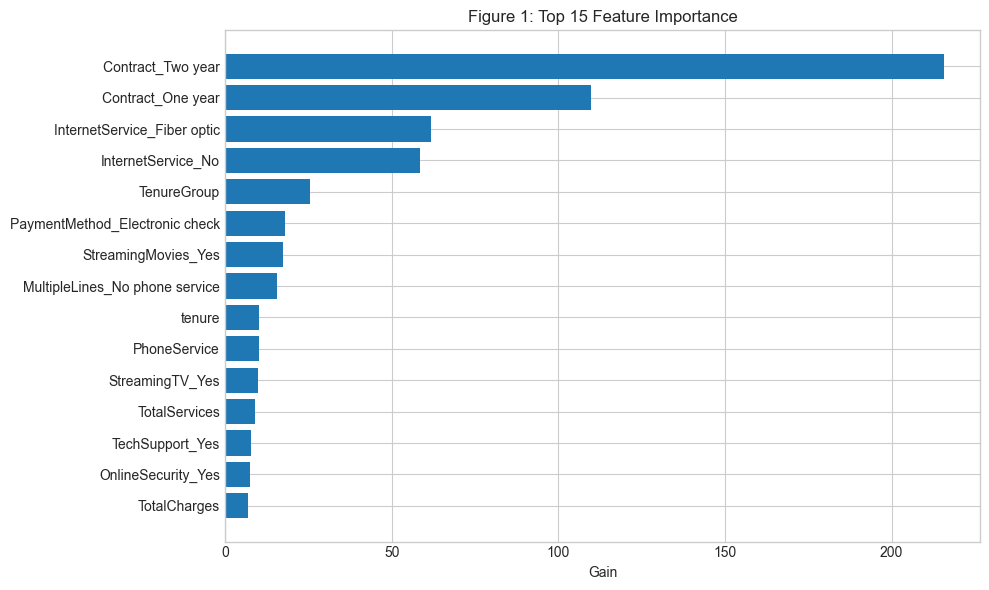

In [6]:
# Generate & save the 5 figures
# Figure 1: Feature Importance
imp = model.get_score(importance_type='gain')
top15 = sorted(imp.items(), key=lambda x: x[1], reverse=True)[:15]
feat, val = zip(*top15)

plt.barh(range(len(feat)), val)
plt.yticks(range(len(feat)), feat)
plt.gca().invert_yaxis()
plt.title('Figure 1: Top 15 Feature Importance')
plt.xlabel('Gain')
plt.tight_layout()
plt.savefig('figures/fig1_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

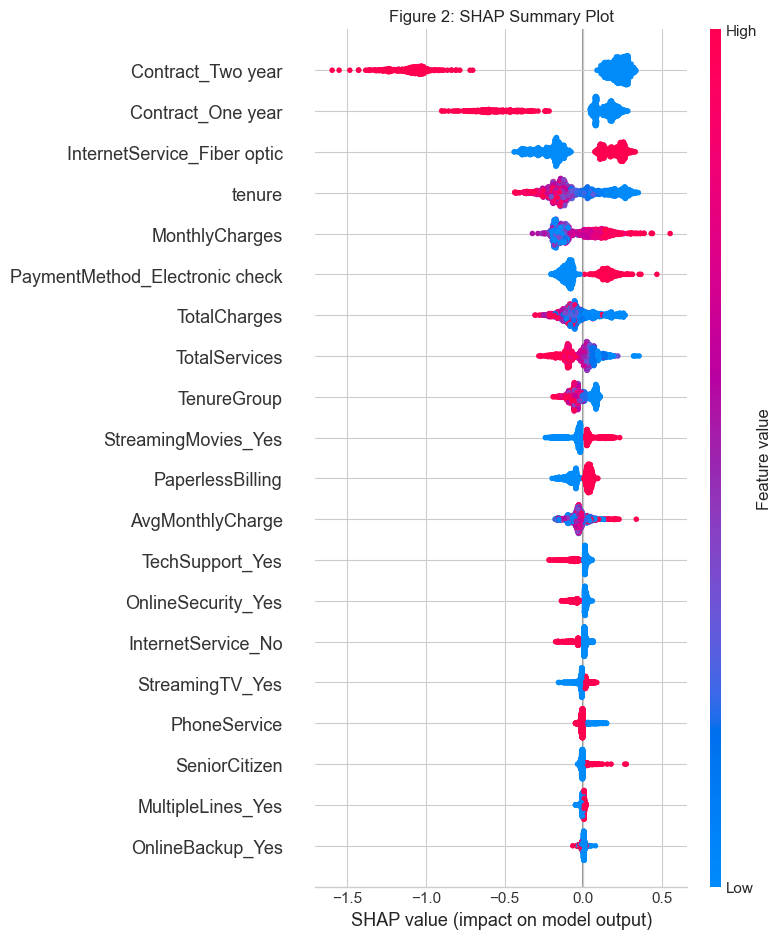

In [7]:
# Figure 2: SHAP Summary (full test set – small enough)
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test)

shap.summary_plot(shap_vals, X_test, show=False)
plt.title('Figure 2: SHAP Summary Plot')
plt.tight_layout()
plt.savefig('figures/fig2_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

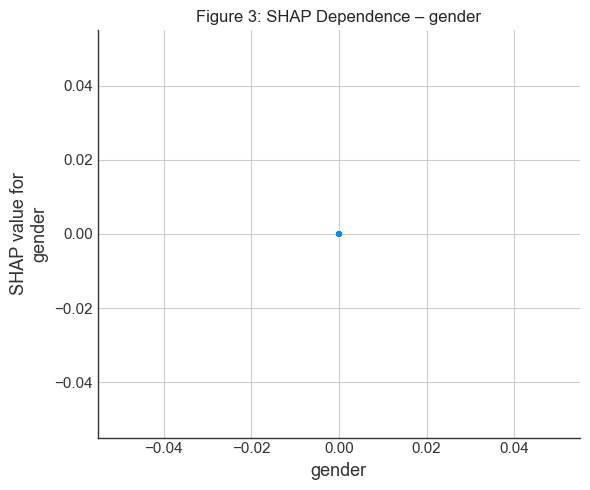

In [8]:
# Figure 3: SHAP Dependence on Contract (Month-to-month is usually top)
# Find the month-to-month column (usually 'Contract_One year' or 'Contract_Two year' – invert for month-to-month)
month_to_month_col = [c for c in X_test.columns if 'Contract' in c and 'month' in c.lower()]
if month_to_month_col:
    contract_col = month_to_month_col[0]
else:
    contract_col = X_test.columns[0]  # fallback

shap.dependence_plot(contract_col, shap_vals, X_test, show=False)
plt.title(f'Figure 3: SHAP Dependence – {contract_col}')
plt.tight_layout()
plt.savefig('figures/fig3_shap_dependence_contract.png', dpi=300, bbox_inches='tight')
plt.show()

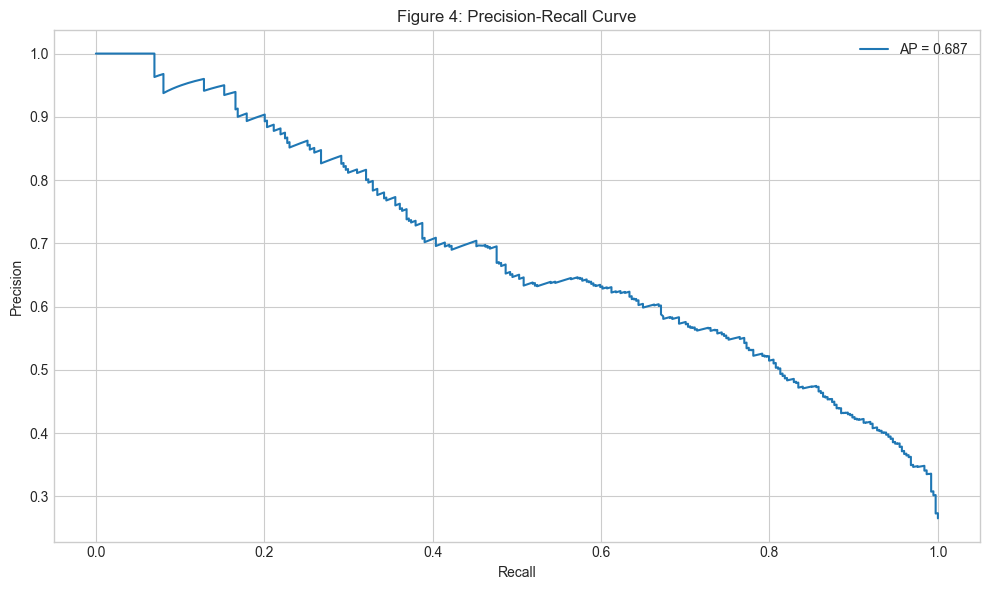

In [9]:
# Figure 4: Precision-Recall Curve
prec, rec, thresh = precision_recall_curve(y_test, prob)
ap = average_precision_score(y_test, prob)

plt.plot(rec, prec, label=f'AP = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Figure 4: Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/fig4_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Create Streamlit app (Figure 5)
streamlit_code = """
import streamlit as st
import joblib
import xgboost as xgb
import pandas as pd

st.title("Telco Customer Churn Risk Calculator")

model = joblib.load('models/final_xgboost_model.pkl')

st.write("Enter customer details:")

tenure = st.slider("Tenure (months)", 0, 72, 12)
monthly = st.number_input("Monthly Charges ($)", 10.0, 150.0, 70.0)
contract_month = st.checkbox("Month-to-Month Contract", value=True)
internet_fiber = st.checkbox("Fiber Optic Internet", value=False)
tech_support = st.checkbox("Has Tech Support", value=False)

input_data = pd.DataFrame(0.0, index=[0], columns=model.feature_names)
input_data['tenure'] = tenure
input_data['MonthlyCharges'] = monthly
if 'Contract_Month-to-month' in input_data.columns:
    input_data['Contract_Month-to-month'] = int(contract_month)
if 'InternetService_Fiber optic' in input_data.columns:
    input_data['InternetService_Fiber optic'] = int(internet_fiber)
if 'TechSupport_Yes' in input_data.columns:
    input_data['TechSupport_Yes'] = int(tech_support)

dmat = xgb.DMatrix(input_data)
prob = model.predict(dmat)[0]
risk = prob * 100

st.metric("Predicted Churn Risk", f"{risk:.1f}%")

if risk > 50:
    st.error("HIGH RISK – immediate outreach recommended")
elif risk > 30:
    st.warning("Elevated risk – consider offer")
else:
    st.success("Low risk")
"""

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

print("Streamlit app saved as streamlit_app.py")
print("Run in terminal: streamlit run streamlit_app.py")
print("Screenshot high-risk example for Figure 5 → save as figures/fig5_streamlit_demo.png")

Streamlit app saved as streamlit_app.py
Run in terminal: streamlit run streamlit_app.py
Screenshot high-risk example for Figure 5 → save as figures/fig5_streamlit_demo.png
